In [26]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

In [27]:
data = yf.download(['V', 'MA'], start='2022-01-01', end='2026-09-01')['Close']

y = data['V']   
x = data['MA']  

[*********************100%***********************]  2 of 2 completed


In [28]:
x_with_constant = sm.add_constant(x)

model = sm.OLS(y, x_with_constant).fit()

hedge_ratio = model.params['MA']
print(f"Hedge Ratio: {hedge_ratio}")

spread = y - (hedge_ratio * x)

Hedge Ratio: 0.6291802426811306


In [29]:
adf_result = adfuller(spread)
p_value = adf_result[1]

print(f"ADF P-Value: {p_value}")
if p_value < 0.05:
    print("The pair is cointegrated")
else:
    print("Not cointegrated")

ADF P-Value: 0.0322936685573405
The pair is cointegrated


C:\Users\nito8\AppData\Local\Temp\ipykernel_22420\1766329505.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(spread)


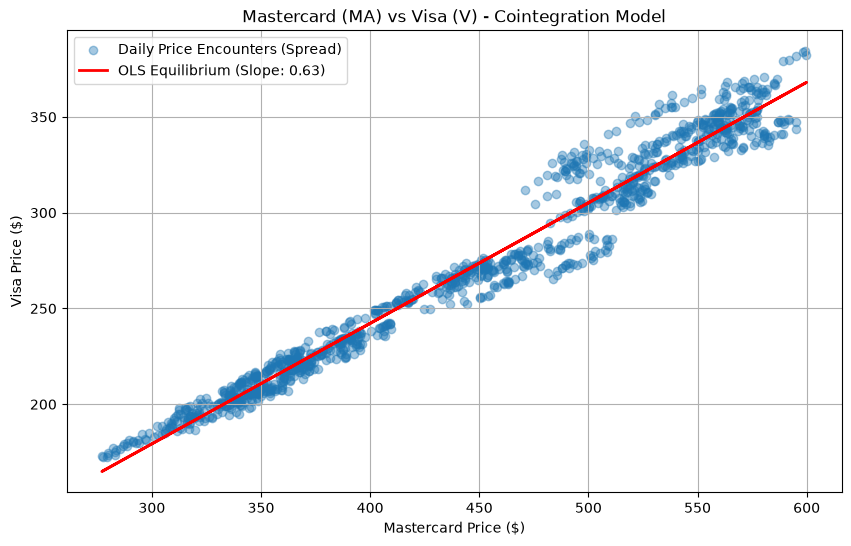

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.4, label='Daily Price Encounters (Spread)')

y_pred = model.predict(x_with_constant)
plt.plot(x, y_pred, color='red', linewidth=2, label=f'OLS Equilibrium (Slope: {hedge_ratio:.2f})')

plt.title('Mastercard (MA) vs Visa (V) - Cointegration Model')
plt.xlabel('Mastercard Price ($)')
plt.ylabel('Visa Price ($)')
plt.legend()
plt.grid(True)
plt.show()

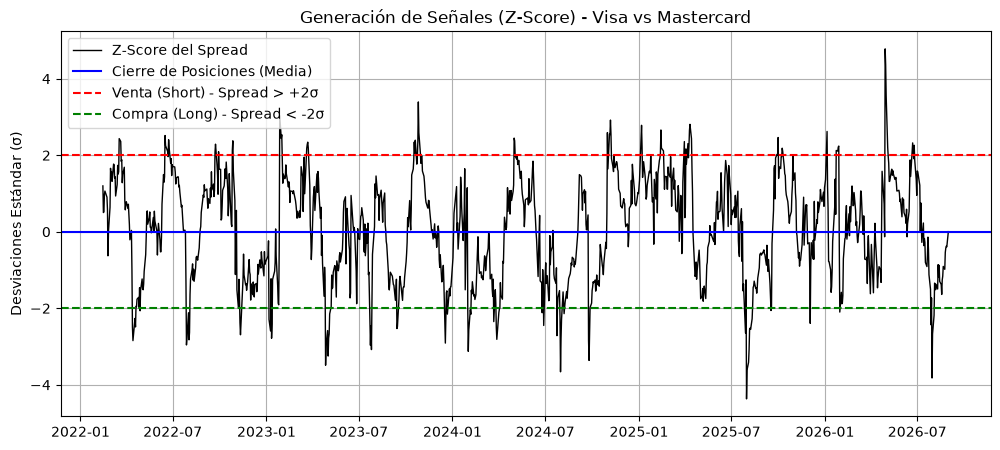

In [31]:
window = 30
rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()

z_score = (spread - rolling_mean) / rolling_std

plt.figure(figsize=(12, 5))
plt.plot(z_score, label='Z-Score del Spread', color='black', linewidth=1)

plt.axhline(0, color='blue', linestyle='-', label='Cierre de Posiciones (Media)')
plt.axhline(2, color='red', linestyle='--', label='Venta (Short) - Spread > +2σ')
plt.axhline(-2, color='green', linestyle='--', label='Compra (Long) - Spread < -2σ')

plt.title('Generación de Señales (Z-Score) - Visa vs Mastercard')
plt.ylabel('Desviaciones Estándar (σ)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
export_data = pd.DataFrame({
    'Price_V': y,
    'Price_MA': x,
    'Z_Score': z_score
})

export_data.dropna(inplace=True)

export_data.to_csv('pairs_signals.csv')
print(f"Exported {len(export_data)} days of trading signals to pairs_signals.csv")